# Video Idea Leads

This notebook finds YouTube video idea leads: videos that performed abnormally well relative to the creator's weight class, not merely videos from already-huge channels. The core heuristic is to look for small or mid-sized channels punching above their subscriber and maturity class (for example, a 10k-subscriber channel getting 1M views), using subscribers, video count, per-video views, and comments as triangulation metrics.

- Default DB path: `data/skimmer.db`
- Override with env var: `SKIMMER_DB_PATH`
- Outputs a composite lead table plus a CSV export in `data/output/`

Algorithm columns:

- `breakout_outliers`: small-channel videos with extreme views-per-subscriber.
- `weight_class_performance`: top percentile videos within subscriber and video-count peer groups.
- `channel_relative`: videos far above their own channel's typical view baseline.
- `velocity`: videos with unusually strong publish velocity or recent re-acceleration.
- `engagement`: videos with unusually high comment/like resonance for their class.
- `topics`: recurring title themes among already-identified outlier leads.

## 1. Setup

In [1]:
import copy
import html
import os
import sys
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import HTML, display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'scripts' / 'RecomendationAnalysis').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise RuntimeError('Could not locate the skimmer repository root from the current directory.')


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from scripts.RecomendationAnalysis import data_access, leads as ra_leads, metrics
from scripts.RecomendationAnalysis.algorithms import topics

DEFAULT_DB_PATH = Path('data/skimmer.db')
_env_db_path = os.environ.get('SKIMMER_DB_PATH')
DB_PATH = Path(_env_db_path).expanduser() if _env_db_path else REPO_ROOT / DEFAULT_DB_PATH
if not DB_PATH.is_absolute():
    DB_PATH = REPO_ROOT / DB_PATH
DB_PATH = data_access.resolve_db_path(DB_PATH)

print(f'Using database: {DB_PATH.resolve()}')

Using database: /home/orangepi/code_projects/skimmer/data/skimmer.db


## 2. Parameters

Edit this single cell to tune the notebook. All downstream cells read from these values.

In [2]:
# PARAMETERS
TOP_N = 100

WEIGHTS = copy.deepcopy(ra_leads.DEFAULT_WEIGHTS)

PARAMS = {
    name: copy.deepcopy(getattr(module, 'DEFAULT_PARAMS', {}))
    for name, module in ra_leads.ALGORITHMS.items()
}
# Keep topic extraction on the stdlib path by default; the sklearn path can be memory-heavy on the full corpus.
PARAMS['topics']['use_sklearn'] = False

FILTERS = {
    'max_per_channel': 3,
    # Optional examples:
    # 'max_subscribers': 200_000,
    # 'min_views': 25_000,
    # 'sub_class': ['1k-10k', '10k-50k', '50k-200k'],
}

EXPORT = True
EXPORT_PATH = REPO_ROOT / 'data' / 'output' / f"{datetime.now().strftime('%Y-%m-%d%H%M%S')}.csv"

display(pd.DataFrame({'algorithm': list(WEIGHTS), 'weight': list(WEIGHTS.values())}))
print(f'Export path: {EXPORT_PATH}')

,algorithm,weight
0,breakout_outliers,1.35
1,weight_class_performance,1.35
2,channel_relative,1.05
3,velocity,0.85
4,engagement,0.60
5,topics,0.35


Export path: /home/orangepi/code_projects/skimmer/data/output/2026-07-31030525.csv


## 3. Data Load + Corpus Summary

In [3]:
# Slow step: loads and enriches the latest video/channel frame and optional video snapshots once.
full_df, snapshots = ra_leads.load_analysis_frame(db_path=DB_PATH, with_snapshots=True)

summary = pd.DataFrame(
    [
        {'metric': 'videos', 'value': len(full_df)},
        {'metric': 'snapshot_rows', 'value': 0 if snapshots is None else len(snapshots)},
        {
            'metric': 'videos_with_2plus_snapshots',
            'value': 0
            if snapshots is None or snapshots.empty
            else int(snapshots.groupby('video_id', observed=True).size().ge(2).sum()),
        },
        {'metric': 'channels', 'value': full_df['channel_id'].nunique() if 'channel_id' in full_df else np.nan},
    ]
)
display(summary)

published = pd.to_datetime(full_df.get('published_at'), errors='coerce', utc=True)
display(pd.DataFrame({'published_at_min': [published.min()], 'published_at_max': [published.max()]}))

class_crosstab = pd.crosstab(full_df['sub_class'], full_df['video_count_class'], dropna=False)
display(class_crosstab)

key_metrics = [
    'subscribers',
    'video_count',
    'views',
    'comments',
    'views_per_sub',
    'channel_relative_multiple',
    'comment_rate',
    'views_per_day',
    'video_age_days',
]
null_rates = (
    full_df[key_metrics]
    .isna()
    .mean()
    .rename('null_rate')
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={'index': 'metric'})
)
display(null_rates)

No usable vidiq channel rows found for 49 missing channels.


,metric,value
0,videos,258454
1,snapshot_rows,488958
2,videos_with_2plus_snapshots,113505
3,channels,10808


,published_at_min,published_at_max
0,2026-06-23 03:10:24+00:00,2026-07-30 17:25:21+00:00


video_count_class,<50,50-300,300-1000,1000+,unknown
sub_class,,,,,
<1k,7178,4586,1363,469,0
1k-10k,8935,14857,5906,5874,0
10k-50k,2695,14058,7630,13225,0
50k-200k,1070,6373,9715,20901,0
200k-1M,309,4161,11497,41463,0
1M+,79,1735,7830,66223,0
unknown,0,0,0,0,322


,metric,null_rate
0,subscribers,0.12
1,video_count,0.12
2,views,0.00
3,comments,1.74
4,views_per_sub,0.14
5,channel_relative_multiple,2.33
6,comment_rate,2.44
7,views_per_day,0.00
8,video_age_days,0.00


## 4. Shared Display Helpers

In [4]:
def _compact_number(value):
    if pd.isna(value):
        return ''
    try:
        number = float(value)
    except (TypeError, ValueError):
        return value
    absolute = abs(number)
    if absolute >= 1_000_000_000:
        return f'{number / 1_000_000_000:.2f}B'
    if absolute >= 1_000_000:
        return f'{number / 1_000_000:.2f}M'
    if absolute >= 1_000:
        return f'{number / 1_000:.1f}k'
    return f'{number:,.0f}'


def _format_value(value):
    if pd.isna(value):
        return ''
    if isinstance(value, (int, np.integer)):
        return f'{value:,}'
    if isinstance(value, (float, np.floating)):
        if abs(value) >= 1000:
            return _compact_number(value)
        return f'{value:.3f}'.rstrip('0').rstrip('.')
    return str(value)


def _anchor(url, text):
    text = '' if pd.isna(text) else str(text)
    if pd.isna(url) or not str(url).strip():
        return html.escape(text)
    return f'<a href="{html.escape(str(url), quote=True)}" target="_blank">{html.escape(text)}</a>'


def display_link_table(frame, columns, limit=25, link_title=True):
    available = [column for column in columns if column in frame.columns]
    table = frame.head(limit).loc[:, available].copy()
    if link_title and 'title' in table.columns and 'video_url' in frame.columns:
        urls = frame.head(limit)['video_url']
        table['title'] = [_anchor(url, title) for url, title in zip(urls, table['title'], strict=False)]
    if 'channel_name' in table.columns and 'channel_url' in frame.columns:
        urls = frame.head(limit)['channel_url']
        table['channel_name'] = [_anchor(url, name) for url, name in zip(urls, table['channel_name'], strict=False)]
    for column in table.columns:
        if column not in {'title', 'channel_name', 'reason', 'algorithms', 'reasons', 'matched_terms', 'category_name'}:
            table[column] = table[column].map(_format_value)
    display(HTML(table.to_html(escape=False, index=False)))


def warn_failures(frame):
    failures = frame.attrs.get('algorithm_failures', {})
    if failures:
        display(HTML('<h3 style="color: #b00020;">WARNING: algorithm failures detected</h3>'))
        display(pd.Series(failures, name='error').to_frame())

## 5. Run Algorithms Once

The next cell is expected to take several minutes on the full corpus. It is shared by every per-algorithm table and by the composite section.

In [5]:
# Slow step: run each scoring algorithm once and reuse these results below.
algorithm_results = ra_leads.run_algorithms(full_df, snapshots=snapshots, params=PARAMS)
algorithm_counts = pd.Series({name: len(frame) for name, frame in algorithm_results.items()}, name='lead_count')
display(algorithm_counts.to_frame())
for frame in algorithm_results.values():
    warn_failures(frame)

,lead_count
breakout_outliers,2495
weight_class_performance,2556
channel_relative,8125
velocity,1665
engagement,8154
topics,5000


### 5.1. Breakout Outliers

Videos with extreme views-per-subscriber, especially from small channels where reach exceeded the built-in audience.

In [6]:
breakout_outliers_top = algorithm_results.get('breakout_outliers', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(breakout_outliers_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'views_per_sub', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,views_per_sub,score,reason
No Celebrity Has ZERO Filter Like Clint Eastwood - and It’s HILARIOUS!,The Fame Fuel,1.5k,5,2.39M,1.6k,28.358,1634.9x views/sub on a 1.5k-sub channel (2.4M views)
Wayne Rooney and Micah Richards angry with Tuchel,Futro,2.0k,27,2.87M,1.4k,27.958,1407.5x views/sub on a 2k-sub channel (2.9M views)
"No words needed,just trust ❤️ #animals #funny #pets #horse",Astmovie001,9.2k,110,8.64M,938.255,27.356,938.3x views/sub on a 9.2k-sub channel (8.6M views)
No One Was Ready for Jim Carrey's Impressions,PapaPrime,1.1k,3,1.37M,1.3k,26.942,1294.8x views/sub on a 1.1k-sub channel (1.4M views)
I pressed C too much #deltarune #undertale,talkalexis,1.1k,676,1.43M,1.3k,26.891,1264.3x views/sub on a 1.1k-sub channel (1.4M views)
#notmine #trending #concert #bensonboone #fun #shorts #tiktok #fyp #viral #meme #jesuslovesyou,April’s World,1.5k,49,1.54M,1.1k,26.292,1057.9x views/sub on a 1.5k-sub channel (1.5M views)
Kwebbelkop Laugh (Original Clip),Develon,1.1k,9,1.18M,1.1k,26.251,1119.7x views/sub on a 1.1k-sub channel (1.2M views)
Naomi Osaka Brings Back Her Signature Wimbledon Look ✨,Punto Final,2.7k,49,2.43M,891.724,26.054,891.7x views/sub on a 2.7k-sub channel (2.4M views)
Nobody Made Michael Jackson Laugh Like Chris Tucker,Chris Wick,6.1k,6,3.25M,534.435,24.329,534.4x views/sub on a 6.1k-sub channel (3.2M views)
Messi & Lamine Yamal - I need you and I miss you,Malik,7.1k,108,3.47M,487.779,24.029,487.8x views/sub on a 7.1k-sub channel (3.5M views)


### 5.2. Weight-Class Performance

Videos ranking at the top of their subscriber and channel-maturity peer group, so the score compares like with like.

In [7]:
weight_class_performance_top = algorithm_results.get('weight_class_performance', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(weight_class_performance_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'composite_raw', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,composite_raw,score,reason
Remember The Clue From Gerson,thym,75,36,60.9k,0.978,1,"top 0.0% of <1k subs / <50 videos peer group (n=7,178)"
China quietly saved the world last month,Max Fisher,384.0k,36,3.98M,0.98,1,top 0.0% of 200k-1M subs / <50 videos peer group (n=309)
Nick Fuentes Interview (Ft. Hunter Biden),Channel 5 with Andrew Callaghan,3.63M,428,4.16M,0.973,1,"top 0.0% of 1M+ subs / 300-1000 videos peer group (n=7,830)"
FINAL FANTASY XIV: Evercold - Extended Teaser Trailer,FINAL FANTASY XIV,739.0k,1.2k,913.3k,0.994,1,"top 0.0% of 200k-1M subs / 1000+ videos peer group (n=41,463)"
Master Set PITCH BLACK in 24 Hours…or Give It All Away (Pokemon Card Challenge),Kyky Rips,124.0k,1.0k,187.7k,0.988,1,"top 0.0% of 50k-200k subs / 1000+ videos peer group (n=20,901)"
Most Ominous Brand Ever,Jeremie,1.6k,48,474.6k,0.981,1,"top 0.0% of 1k-10k subs / <50 videos peer group (n=8,935)"
NVIDIA Keynote Live at SIGGRAPH 2026,NVIDIA,2.23M,2.7k,7.40M,0.998,1,"top 0.0% of 1M+ subs / 1000+ videos peer group (n=66,223)"
BODY POSITIONS!#cheerleader #cheer #cheerleading #stretching #flyer #flexible www.kinsleypetty.com,Kinsley Petty,36.1k,1.2k,151.8k,0.994,1,"top 0.0% of 10k-50k subs / 1000+ videos peer group (n=13,225)"
Scammer CRIES After I HACK Her Live Webcam!,NanoBaiter,1.24M,24,5.41M,0.949,1,top 0.0% of 1M+ subs / <50 videos peer group (n=79)
Something Won't Let You Leave...,ThatMob,2.32M,73,13.01M,0.987,1,"top 0.0% of 1M+ subs / 50-300 videos peer group (n=1,735)"


### 5.3. Channel Relative

Videos that beat their own channel baseline by a large multiple, indicating an idea that overperformed the creator's usual demand.

In [8]:
channel_relative_top = algorithm_results.get('channel_relative', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(channel_relative_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'channel_relative_multiple', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,channel_relative_multiple,score,reason
Spain 2026 FIFA World Cup Champions 🏆Trophy Ceremony,Michael Anthony Videos,42.8k,1.2k,13.63M,16.8k,11.67,"17kx its channel's median (median 813 -> 14M views, n=69 videos)"
Property owner warns others to fight back after squatter takeover,ABC 10 News,425.0k,82.4k,1.31M,2.0k,9.572,"2kx its channel's median (median 644 -> 1M views, n=107 videos)"
War Of Words Between Education Minister Dharmendra Pradhan Vs Rahul Gandhi in Lok Sabha | News Buzz,News Buzz,2.30M,36.3k,6.52M,2.7k,9.505,"3kx its channel's median (median 2k -> 7M views, n=93 videos)"
"The Shards | Official Trailer | Igby Rigney, Kaia Gerber, Hayes Warner | FX",FX Networks,682.0k,6.6k,24.20M,2.0k,9.357,"2kx its channel's median (median 12k -> 24M views, n=52 videos)"
I Play Rocky | Official Trailer,Amazon MGM Studios,1.81M,2.5k,19.27M,4.1k,9.181,"4kx its channel's median (median 5k -> 19M views, n=36 videos)"
Pembe VS Mavi Kek Dekorasyon Mücadelesi | Eğlenceli Anlar,KiKaDo Turkish,36.3k,218,8.72M,1.4k,9.015,"1kx its channel's median (median 6k -> 9M views, n=65 videos)"
THE UPRISING - Official Trailer [HD] - Only In Theaters September 11,Focus Features,1.06M,2.5k,17.48M,5.2k,8.848,"5kx its channel's median (median 3k -> 17M views, n=33 videos)"
Dune: Part Three | Official Trailer,Warner Bros.,12.90M,3.7k,33.33M,1.5k,8.747,"2kx its channel's median (median 22k -> 33M views, n=60 videos)"
WERWULF - Official Trailer [HD] - Only In Theaters Christmas,Focus Features,1.06M,2.5k,15.91M,4.8k,8.736,"5kx its channel's median (median 3k -> 16M views, n=33 videos)"
Lioness | Season 3 Official Trailer | Paramount+,Paramount Plus,2.25M,106.4k,9.86M,1.2k,8.647,"1kx its channel's median (median 8k -> 10M views, n=75 videos)"


### 5.4. Velocity

Videos with unusually high views-per-day or observed recent acceleration from snapshot history.

In [9]:
velocity_top = algorithm_results.get('velocity', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(velocity_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'observed_views_per_day', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,observed_views_per_day,score,reason
Spain 2026 FIFA World Cup Champions 🏆Trophy Ceremony,Michael Anthony Videos,42.8k,1.2k,13.63M,188.2k,99.705,top 1% views/day in 10k-50k/1000+ class
Messi & Lamine Yamal - I need you and I miss you,Malik,7.1k,108,3.47M,,99.563,top 1% views/day in 1k-10k/50-300 class
Mama Cat Trims Fur on the Farm and Makes Tiger Hat For Kittens At Home🐾🎩🐯,Simple Happy Life,8.9k,21,1.21M,,99.544,top 1% views/day in 1k-10k/<50 class
Robert Smith “PlainSong… And… HelLo Here AgAin !…“ - The CuRE @ BerLin - 12.07.2026,Linkeyes,3.4k,1.1k,854.5k,37.0k,99.326,top 1% views/day in 1k-10k/1000+ class
"No words needed,just trust ❤️ #animals #funny #pets #horse",Astmovie001,9.2k,110,8.64M,,99.077,top 1% views/day in 1k-10k/50-300 class
LA VELADA DEL AÑO VI,Ibai,17.10M,2.5k,60.84M,,99.003,top 1% views/day in 1M+/1000+ class
Yash | Ramayana | San Diego Comic-Con 2026,FANVERSATION,3.7k,1.2k,320.3k,90.8k,99,top 1% views/day in 1k-10k/1000+ class
112. (M55kg) MANDENGBAM Jadumani Singh (IND)_WON 5.0 vs MWALE Mwengo (ZAM) Commonwealth Games 2026,Boxing,3.5k,2.8k,86.5k,,98.954,top 1% views/day in 1k-10k/1000+ class
I pressed C too much #deltarune #undertale,talkalexis,1.1k,676,1.43M,,98.725,top 1% views/day in 1k-10k/300-1000 class
He digs a trench every night for this reason,BrainFuel TV,6.3k,19,879.3k,,98.685,top 1% views/day in 1k-10k/<50 class


### 5.5. Engagement

Videos with unusual comment resonance for their subscriber class, useful for finding polarizing, question-heavy, or high-intent ideas.

In [10]:
engagement_top = algorithm_results.get('engagement', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(engagement_top, ['title', 'channel_name', 'subscribers', 'video_count', 'views', 'comment_rate_z', 'score', 'reason'], limit=25)

title,channel_name,subscribers,video_count,views,comment_rate_z,score,reason
"🧾God says, you’ve been given a lot of money. If you don’t listen to God, you won’t receive the money",God Miracles Today 11:11,280.0k,1.5k,10.4k,370.42,7.016,"comment rate 482.1x class norm (91.8% of viewers commented, 9.6k comments)"
🧾God is speaking in anger today. You made a mistake that heaven noticed. Don’t walk away from this,God Miracles Today 11:11,280.0k,1.5k,12.6k,346.144,6.948,"comment rate 450.5x class norm (85.8% of viewers commented, 10.8k comments)"
"🧾God says, your miracle just arrived, but this is your final warning. If you skip, it will be taken",God Miracles Today 11:11,280.0k,1.5k,11.0k,334.548,6.915,"comment rate 435.5x class norm (82.9% of viewers commented, 9.1k comments)"
"Chosen One, God Warns: This Moment Only Comes Once In A Lifetime.",Divine Whisper,22.0k,59,64.7k,186.668,6.339,"comment rate 277.8x class norm (35.6% of viewers commented, 23.0k comments)"
"God Says: My Child, July Will Overflow with Blessings | God Message Today | God Message Now",JESUS LAST MESSAGE,27.5k,276,12.4k,173.706,6.259,"comment rate 258.5x class norm (33.1% of viewers commented, 4.1k comments)"
"Chosen One, Your Money Has Been Released In Heaven. It Is Waiting For You To...",Divine Whisper,22.0k,59,13.3k,159.06,6.177,"comment rate 236.8x class norm (30.3% of viewers commented, 4.0k comments)"
"Chosen One, Your Miracle From God Has Arrived. Your Days of Waiting Are Over",Divine Whisper,22.0k,59,18.4k,151.79,6.131,"comment rate 226.0x class norm (28.9% of viewers commented, 5.3k comments)"
الرجل العنكبوت انقاذ باتمان Spider-Man Rescue batman vs iron man vs venom funny Game GTA 5 superhero,Supper Gta,441,14,10.4k,108.891,6.044,"premium lead; comment rate 109.9x class norm (17.1% of viewers commented, 1.8k comments)"
"God Says: ""IT'S COMING FOR YOU"" | A Powerful Message From God Today | God Message Now",JESUS LAST MESSAGE,27.5k,276,16.0k,131.422,5.981,"comment rate 195.8x class norm (25.1% of viewers commented, 4.0k comments)"
Monday July 20 Powerful Morning Prayer To Start Your Day With God Prayer for Blessings Grace & Favor,Prayer Flow,9.8k,125,11.4k,107.831,5.79,"comment rate 160.9x class norm (10.0% of viewers commented, 1.1k comments)"


### 5.6. Topics

Lead videos whose title terms recur across multiple outliers, boosted by theme lift and niche undersaturation.

In [11]:
topics_top = algorithm_results.get('topics', pd.DataFrame()).sort_values('score', ascending=False)
display_link_table(topics_top, ['title', 'channel_name', 'subscribers', 'views', 'matched_terms', 'theme_lift', 'score', 'reason'], limit=25)

title,channel_name,subscribers,views,matched_terms,theme_lift,score,reason
Superheroes On A Motorcycle Ride Over The Sea Along The Supper& Spider-Man Bridge GTA 5,BeamNG Yeet,1.7k,14.0k,bridge gta | motorcycle | bridge | spider man | spider,8.472,41.674,"Matches hot theme(s): bridge gta, motorcycle, bridge; avg lift 8.5x; niche saturation 0.0023."
Argentina 🇦🇷 Vs Switzerland 🇨🇭 | 2026 FIFA World Cup,IShowSpeed,59.60M,22.07M,argentina | fifa world | fifa | world cup | cup,3.99,40.367,"Matches hot theme(s): argentina, fifa world, fifa; avg lift 4.0x; niche saturation 0.0023."
Argentina 🇦🇷 Vs Cape Verde 🇨🇻 | 2026 FIFA World Cup,IShowSpeed,59.60M,38.88M,argentina | fifa world | fifa | world cup | cup,3.99,40.367,"Matches hot theme(s): argentina, fifa world, fifa; avg lift 4.0x; niche saturation 0.0023."
SPIDER-MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE | GTA MULTIVERSE5,MARINARA,73.0k,2.40M,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."
SPIDER-MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE | GTA MULTIVERSE5,MARINARA,73.0k,1.27M,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."
SPIDER-MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE | GTA MULTIVERSE5,MARINARA,73.0k,358.6k,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."
SPIDER-MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE | GTA MULTIVERSE5,MARINARA,73.0k,561.8k,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."
SPIDER-MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE | GTA MULTIVERSE5,MARINARA,73.0k,676.6k,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."
SPIDER-MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE | GTA MULTIVERSE5,MARINARA,73.0k,708.9k,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."
SPIDER MAN against TUNG TUNG TUNG SAHUR on Motorcycle in RAINBOW SPIDERS BRIDGE GTA MULTIVERSE11,MARINARA,73.0k,809.4k,bridge gta | motorcycle | rainbow | bridge | spider man,8.645,40.098,"Matches hot theme(s): bridge gta, motorcycle, rainbow; avg lift 8.6x; niche saturation 0.0023."


## 6. Composite Leads

The composite score blends normalized algorithm ranks with the weights from the parameters cell and a small corroboration bonus for videos hit by multiple algorithms.

In [12]:
normalized_results = ra_leads.normalize_scores(algorithm_results)

_original_load_analysis_frame = ra_leads.load_analysis_frame
_original_run_algorithms = ra_leads.run_algorithms

def _cached_load_analysis_frame(*args, **kwargs):
    return full_df, snapshots

def _cached_run_algorithms(*args, **kwargs):
    return algorithm_results

try:
    ra_leads.load_analysis_frame = _cached_load_analysis_frame
    ra_leads.run_algorithms = _cached_run_algorithms
    composite_leads = ra_leads.generate_leads(
        db_path=DB_PATH,
        top_n=TOP_N,
        weights=WEIGHTS,
        params=PARAMS,
        filters=FILTERS,
        export_path=None,
    )
finally:
    ra_leads.load_analysis_frame = _original_load_analysis_frame
    ra_leads.run_algorithms = _original_run_algorithms

# Preserve the counts from the one shared algorithm run used above.
composite_leads.attrs['algorithm_counts'] = {name: len(frame) for name, frame in algorithm_results.items()}
composite_leads.attrs['algorithm_failures'] = {
    name: error
    for result in algorithm_results.values()
    for name, error in result.attrs.get('algorithm_failures', {}).items()
}

warn_failures(composite_leads)
display(pd.Series(composite_leads.attrs.get('algorithm_counts', {}), name='lead_count').to_frame())

composite_columns = [
    'title',
    'channel_name',
    'subscribers',
    'video_count',
    'views',
    'views_per_sub',
    'channel_relative_multiple',
    'algorithms_hit',
    'composite_score',
    'algorithms',
    'reasons',
]
display_link_table(composite_leads, composite_columns, limit=50)

display(composite_leads['algorithms_hit'].value_counts().sort_index().rename_axis('algorithms_hit').to_frame('lead_count'))
display(composite_leads['sub_class'].value_counts().sort_index().rename_axis('sub_class').to_frame('lead_count'))

,lead_count
breakout_outliers,2495
weight_class_performance,2556
channel_relative,8125
velocity,1665
engagement,8154
topics,5000


title,channel_name,subscribers,video_count,views,views_per_sub,channel_relative_multiple,algorithms_hit,composite_score,algorithms,reasons
Angry Birds Movie [ 4K 60fps ] ( Best right-wing propaganda movie ever ),PredakingAE,7.7k,369,2.36M,308.415,213.595,6,8.086,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","308.4x views/sub on a 7.7k-sub channel (2.4M views) | top 0.0% of 1k-10k subs / 300-1000 videos peer group (n=5,906) | 294x its channel's median (median 8k -> 2M views, n=7 videos) | top 1% views/day in 1k-10k/300-1000 class | premium lead; comment rate 12.2x class norm (0.8% of viewers commented, 17.9k comments) | Matches hot theme(s): birds movie, angry birds, angry; avg lift 7.2x; niche saturation 0.0033."
¿Por qué tantos celebran la derrota de Argentina en el Mundial?,José Manuel Valladares,4.4k,422,433.9k,97.729,197.955,6,8.068,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","97.7x views/sub on a 4.4k-sub channel (433.9k views) | top 0.1% of 1k-10k subs / 300-1000 videos peer group (n=5,906) | 202x its channel's median (median 2k -> 434k views, n=14 videos) | top 1% views/day in 1k-10k/300-1000 class | premium lead; comment rate 13.1x class norm (0.8% of viewers commented, 3.5k comments) | Matches hot theme(s): argentina mundial, derrota, argentina; avg lift 10.1x; niche saturation 0.0029."
I Would Never Move to America” — A Brit Said This,Quin,4.5k,86,698.8k,157.041,237.134,6,7.959,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","157.0x views/sub on a 4.5k-sub channel (698.8k views) | top 0.1% of 1k-10k subs / 50-300 videos peer group (n=14,857) | 258x its channel's median (median 3k -> 699k views, n=29 videos) | top 1% views/day in 1k-10k/50-300 class | premium lead; comment rate 6.5x class norm (0.4% of viewers commented, 2.8k comments) | Matches hot theme(s): move america, brit, america; avg lift 4.8x; niche saturation 0.0027."
World Cup Fans Broke Down After Seeing the America Nobody Told Them About,Soccer Storm Report,3.7k,113,1.35M,363.116,956.312,6,7.872,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","363.1x views/sub on a 3.7k-sub channel (1.4M views) | top 0.2% of 1k-10k subs / 50-300 videos peer group (n=14,857) | 970x its channel's median (median 1k -> 1M views, n=50 videos) | top 1% views/day in 1k-10k/50-300 class | premium lead; comment rate 4.1x class norm (0.3% of viewers commented, 3.4k comments) | Matches hot theme(s): cup fans, world cup, cup; avg lift 3.1x; niche saturation 0.0033."
The Game VS YG Go Head to Head WHO WON ?,KING REDZZ,3.3k,470,474.6k,145.587,694.893,6,7.548,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","145.6x views/sub on a 3.3k-sub channel (474.6k views) | top 0.2% of 1k-10k subs / 300-1000 videos peer group (n=5,906) | 695x its channel's median (median 683 -> 475k views, n=52 videos) | top 1% views/day in 1k-10k/300-1000 class | premium lead; comment rate 4.9x class norm (0.3% of viewers commented, 1.5k comments) | Matches hot theme(s): won, head, go; avg lift 1.4x; niche saturation 0.0033."
"The ""Hot Felon"" 12 Years Later: Where Is Jeremy Meeks Now?",Weekly True Crime News Mama,2.7k,338,296.3k,110.972,316.556,6,7.367,"breakout_outliers,weight_class_performance,channel_relative,velocity,engagement,topics","111.0x views/sub on a 2.7k-sub channel (296.3k views) | top 0.1% of 1k-10k subs / 300-1000 videos peer group (n=5,906) | 319x its channel's median (median 929 -> 296k views, n=29 videos) | top 1% views/day in 1k-10k/300-1000 class | premium lead; comment rate 8.1x class norm (0.5% of viewers commented, 1.5k comments) | Matches hot theme(s): years later, years, hot; avg lift 1.4x; niche saturation 0.0033."
"EGYPT WERE ROBBED!"" 🇪🇬 Mourinho, Henry & Shearer GO MAD At Stunned VAR Referees!",SOCCER 80 QUIZ,5.6k,229,481.8k,85.879,474.428,6,7.331,"breakout_outliers,weight_cl

,lead_count
algorithms_hit,
4,8
5,67
6,25


,lead_count
sub_class,
<1k,22
1k-10k,59
10k-50k,17
50k-200k,1
200k-1M,0
1M+,1
unknown,0


## 7. Visualisation

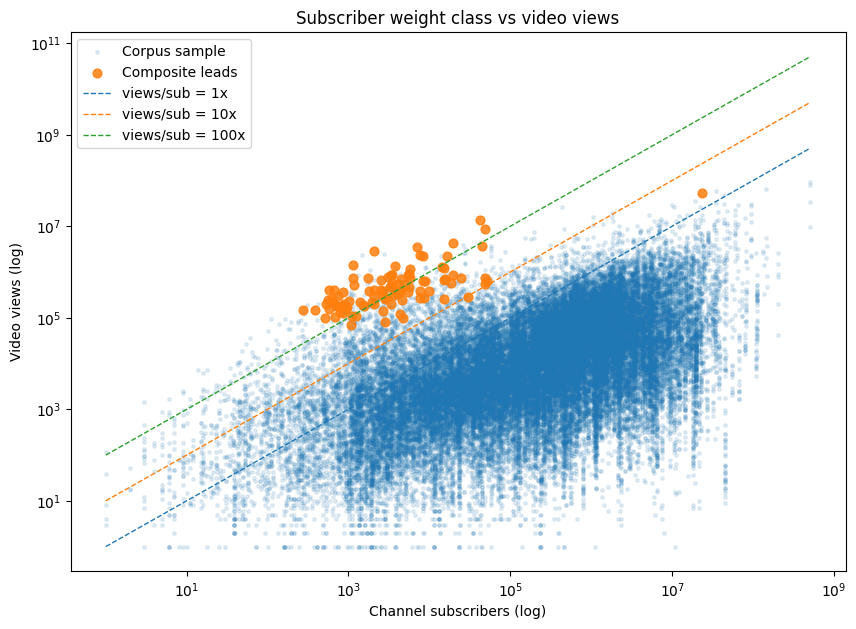

In [13]:
import matplotlib.pyplot as plt

plot_df = full_df[['video_id', 'subscribers', 'views', 'sub_class', 'views_per_sub']].copy()
plot_df['subscribers'] = pd.to_numeric(plot_df['subscribers'], errors='coerce')
plot_df['views'] = pd.to_numeric(plot_df['views'], errors='coerce')
plot_df = plot_df[(plot_df['subscribers'] > 0) & (plot_df['views'] > 0)]

# Downsample the 258k-row background so the notebook remains responsive.
background_plot = plot_df.sample(n=min(50_000, len(plot_df)), random_state=42)
lead_ids = set(composite_leads['video_id'].astype(str))
lead_plot = plot_df[plot_df['video_id'].astype(str).isin(lead_ids)]

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(background_plot['subscribers'], background_plot['views'], s=6, alpha=0.12, label='Corpus sample')
ax.scatter(lead_plot['subscribers'], lead_plot['views'], s=40, alpha=0.85, label='Composite leads')

x_min = max(plot_df['subscribers'].min(), 1)
x_max = plot_df['subscribers'].max()
x_values = np.logspace(np.log10(x_min), np.log10(x_max), 200)
for multiple in (1, 10, 100):
    ax.plot(x_values, x_values * multiple, linestyle='--', linewidth=1, label=f'views/sub = {multiple}x')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Channel subscribers (log)')
ax.set_ylabel('Video views (log)')
ax.set_title('Subscriber weight class vs video views')
ax.legend()
plt.show()

/tmp/ipykernel_500083/148484384.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(box_data, labels=order, showfliers=False)


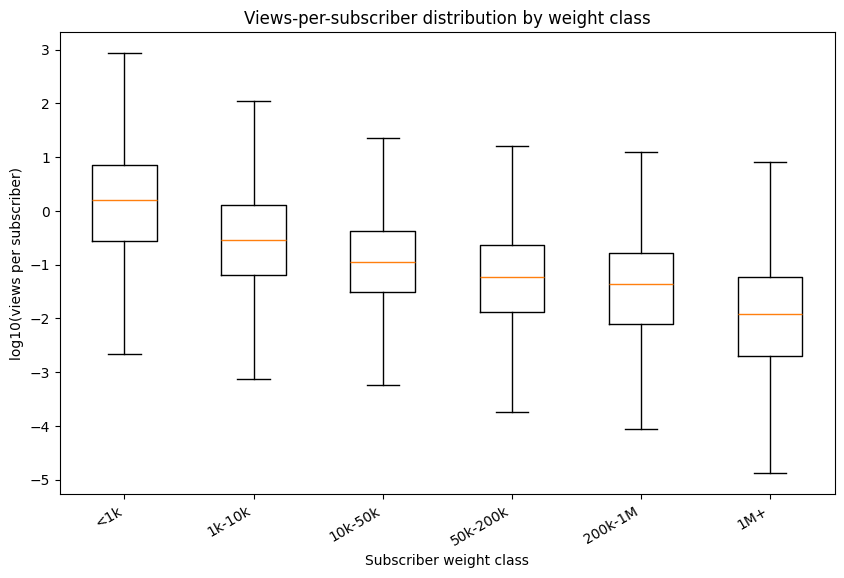

In [14]:
distribution_df = full_df[['sub_class', 'views_per_sub']].copy()
distribution_df['views_per_sub'] = pd.to_numeric(distribution_df['views_per_sub'], errors='coerce')
distribution_df = distribution_df[np.isfinite(distribution_df['views_per_sub']) & (distribution_df['views_per_sub'] > 0)]
distribution_df['log10_views_per_sub'] = np.log10(distribution_df['views_per_sub'].clip(lower=1e-6))

order = [label for label in metrics.SUB_WEIGHT_CLASSES if label in set(distribution_df['sub_class'].astype(str))]
box_data = [
    distribution_df.loc[distribution_df['sub_class'].astype(str).eq(label), 'log10_views_per_sub'].sample(
        n=min(20_000, distribution_df['sub_class'].astype(str).eq(label).sum()),
        random_state=42,
    )
    for label in order
]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(box_data, labels=order, showfliers=False)
ax.set_xlabel('Subscriber weight class')
ax.set_ylabel('log10(views per subscriber)')
ax.set_title('Views-per-subscriber distribution by weight class')
plt.xticks(rotation=30, ha='right')
plt.show()

## 8. Themes & Niches

`topics.extract_themes` finds recurring lead-title terms with lift versus the full background corpus. `topics.niche_saturation` summarizes categories where outliers concentrate. Read `saturation_score` as: high outlier rate plus comparatively few distinct channels means a potentially underserved niche.

In [15]:
theme_params = copy.deepcopy(PARAMS.get('topics', {}))
top_themes = topics.extract_themes(composite_leads, background=full_df, **theme_params).head(30)
display(top_themes)

niche_saturation = topics.niche_saturation(full_df, composite_leads, **theme_params)
display(niche_saturation)

,term,ngram_size,lead_count,lead_share,background_share,lift,median_views,median_views_per_sub,distinct_channels,example_titles,example_video_ids
0,birds movie,2,8,0.08,0.000244,361.983193,370341.5,287.093445,8,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | 3AiBBkeqjBs | HsD6HJ_zMdo
1,flower man,2,5,0.05,0.000217,271.487395,237820.0,235.465347,5,Rubies man - Flower man but it's sung by Morsh...,xYVftJPcF0Y | ZJMtfpjETIc | 37BJRpCgw7M
2,angry birds,2,8,0.08,0.000565,156.198227,370341.5,287.093445,8,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | 3AiBBkeqjBs | HsD6HJ_zMdo
3,angry,1,9,0.09,0.001161,84.462745,514716.0,308.414902,9,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | 3AiBBkeqjBs | HsD6HJ_zMdo
4,flower,1,5,0.05,0.000484,121.626353,237820.0,235.465347,5,Rubies man - Flower man but it's sung by Morsh...,xYVftJPcF0Y | ZJMtfpjETIc | 37BJRpCgw7M
5,birds,1,8,0.08,0.001180,74.770299,370341.5,287.093445,8,Angry Birds Movie [ 4K 60fps ] ( Best right-w...,uPpoN0EhnlQ | 3AiBBkeqjBs | HsD6HJ_zMdo
6,european fans,2,3,0.03,0.000310,126.694118,385769.0,215.513408,3,European Fans Mocked U.S. Stadiums… Until They...,I1UAMu3jrQ8 | GiBHHfoz1ZY | SUQrh0rTaLU
7,europeans,1,9,0.09,0.002585,37.932371,205168.0,121.909804,8,Europeans Thought America's National Anthem Wa...,9nbV9CmCbEM | cGV-9-IC-TY | Yi5JJ4h7_Zs
8,kindness,1,3,0.03,0.000488,80.440710,264915.0,91.125316,3,"""We Have ZERO Kindness Like This Back Home!"" E...",cGV-9-IC-TY | ecwpf49O-4I | xmG50FqWGmk
9,fifa,1,10,0.10,0.003858,27.956576,357528.5,101.719436,9,FIFA Drops Hammer on Argentina 😱 | FIFA Faces ...,Dn1s8difRtI | swo3KYo03_Y | AKbc8VroSXM


,category_id,category_name,distinct_channels,outlier_channels,total_videos,outlier_videos,outlier_rate,median_outlier_subscribers,saturation_score
0,19,Travel & Events,210,3,2373,3,0.001264,4580.0,0.000236
1,2,Autos & Vehicles,241,1,3171,2,0.000631,48500.0,0.000115
2,23,Comedy,284,3,4886,3,0.000614,3050.0,0.000109
3,28,Science & Technology,270,1,3434,2,0.000582,4380.0,0.000104
4,22,People & Blogs,2522,35,46308,37,0.000799,2040.0,0.000102
5,17,Sports,801,9,23479,10,0.000426,6450.0,0.000064
6,27,Education,609,4,10687,4,0.000374,3375.0,0.000058
7,24,Entertainment,2464,18,46050,19,0.000413,5550.0,0.000053
8,10,Music,1443,9,26796,9,0.000336,1740.0,0.000046
9,20,Gaming,1484,5,28157,6,0.000213,2245.0,0.000029


## 9. Export

In [16]:
if EXPORT:
    export_path = ra_leads.export_leads(composite_leads, EXPORT_PATH)
    composite_leads.attrs['export_path'] = str(export_path.resolve())
    print(f'Wrote composite leads CSV: {export_path.resolve()}')
else:
    composite_leads.attrs['export_path'] = None
    print('EXPORT is False; no CSV written.')

Wrote composite leads CSV: /home/orangepi/code_projects/skimmer/data/output/2026-07-31030525.csv
